In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv(r'E:/student-mat.csv')

# =========================
# 2. Kiểm tra dữ liệu
# =========================
print("5 dòng đầu của dữ liệu:")
print(df.head())

print("\nThông tin dữ liệu:")
print(df.info())

# =========================
# 3. Kiểm tra Missing Values
# =========================
print("\nSố lượng giá trị thiếu:")
print(df.isnull().sum())

# =========================
# 4. Chọn thuộc tính dùng để phân cụm
# =========================
features = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[features]

# =========================
# 5. Chuẩn hóa dữ liệu
# =========================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Chuyển về DataFrame để dễ xem
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# =========================
# 6. Hiển thị kết quả
# =========================
print("\nDữ liệu sau khi chuẩn hóa:")
print(X_scaled_df.head())

5 dòng đầu của dữ liệu:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeI

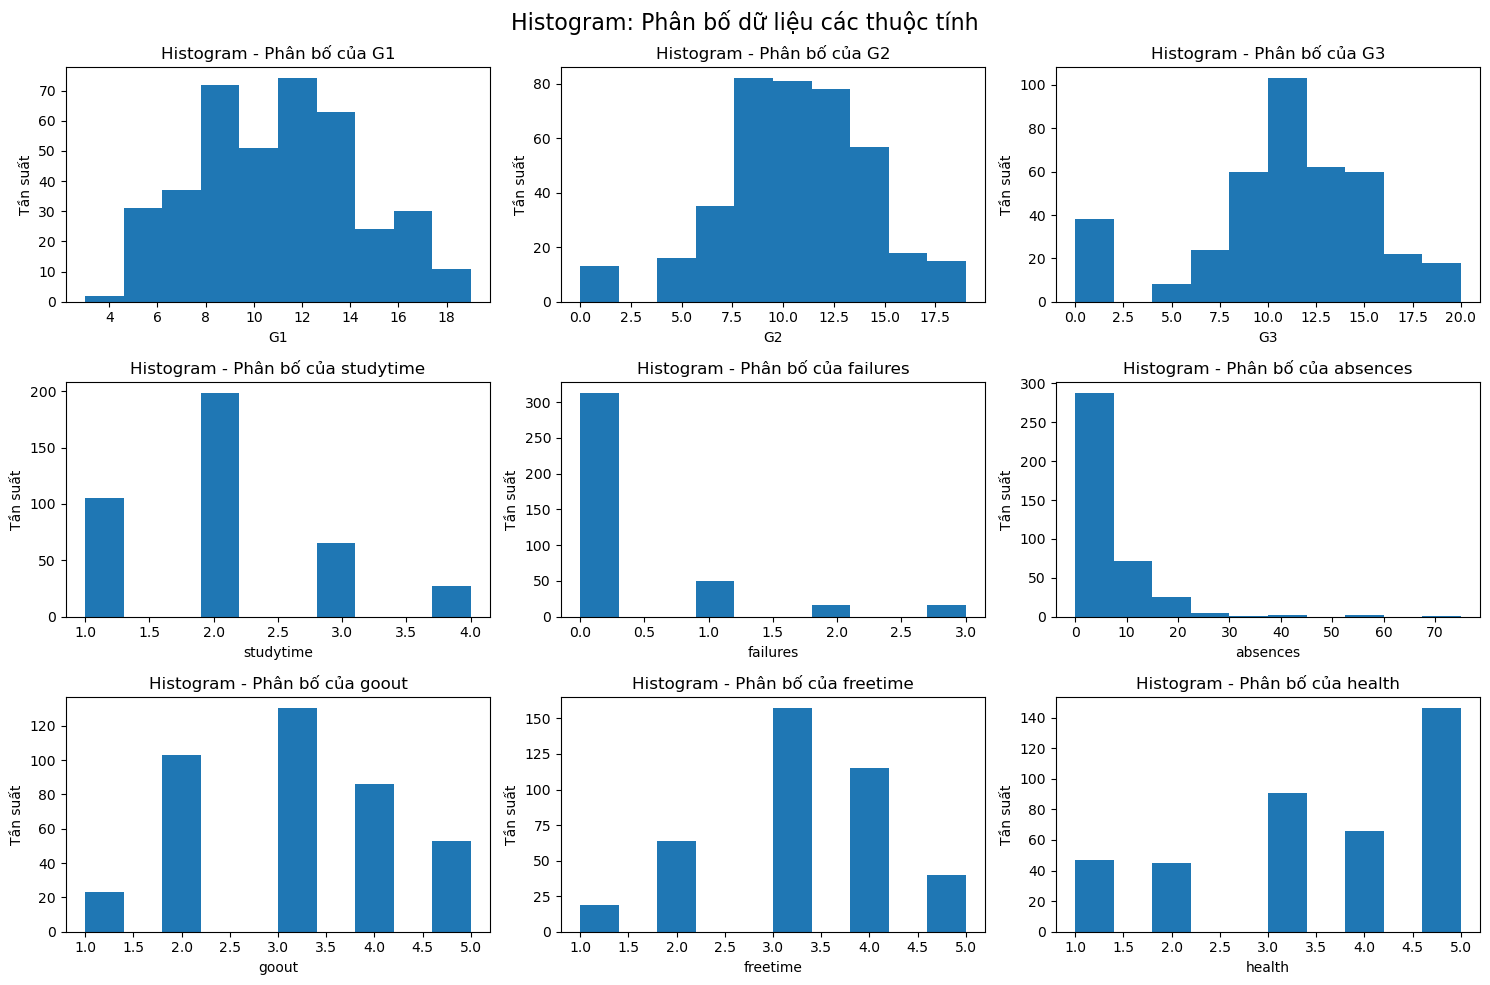

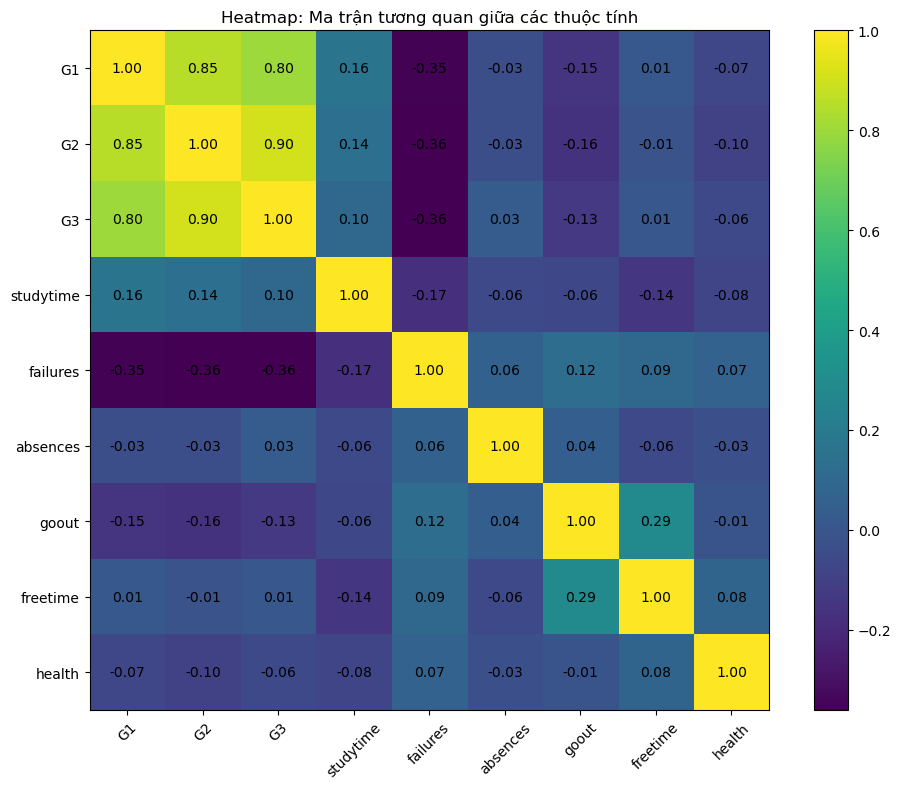

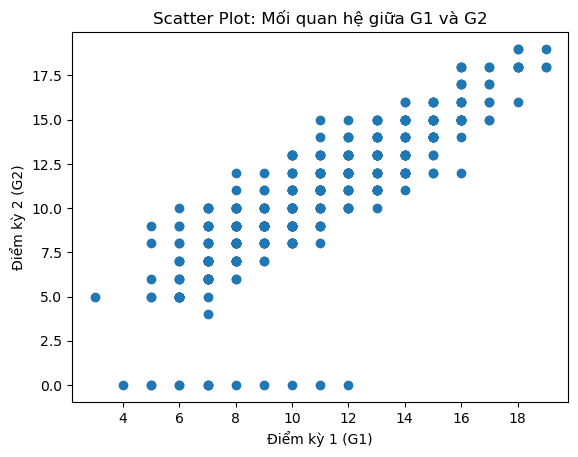

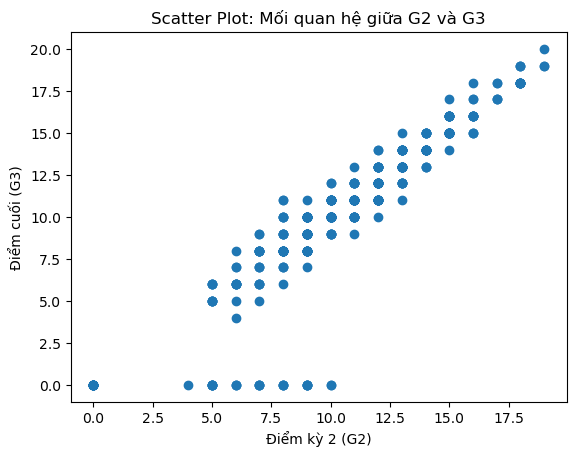

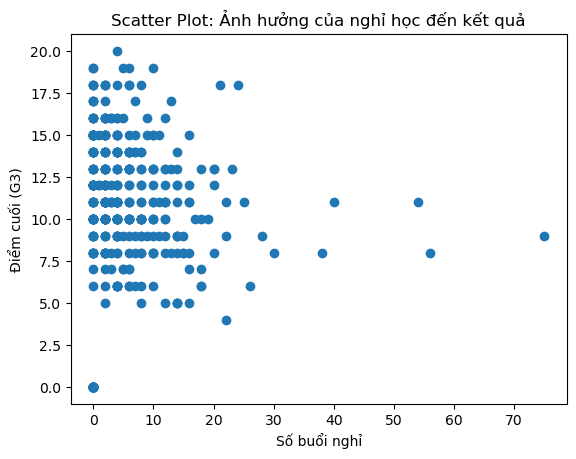

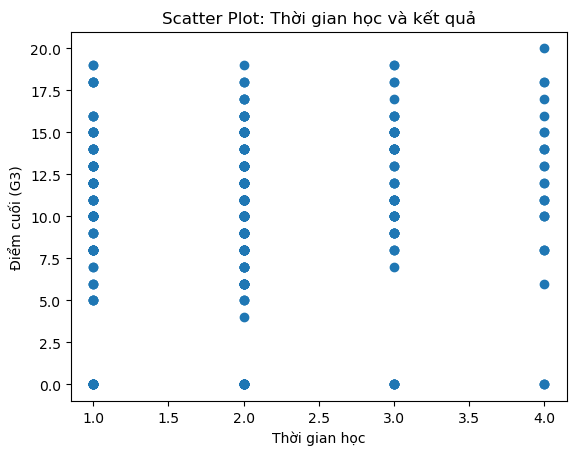


✅ Đã hiển thị đầy đủ: Histogram, Heatmap, Scatter Plot


In [26]:
2.2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv(r'E:/student-mat.csv', sep=',')

# =========================
# 2. Chọn các thuộc tính số
# =========================
cols = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

data = df[cols]

# =========================
# 3. HISTOGRAM
# =========================
plt.figure(figsize=(15,10))

for i, col in enumerate(cols):
    plt.subplot(3, 3, i+1)
    plt.hist(data[col], bins=10)
    plt.title(f'Histogram - Phân bố của {col}')
    plt.xlabel(col)
    plt.ylabel('Tần suất')

plt.suptitle('Histogram: Phân bố dữ liệu các thuộc tính', fontsize=16)
plt.tight_layout()
plt.show()

# =========================
# 4. HEATMAP
# =========================
corr = data.corr()

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)

plt.title('Heatmap: Ma trận tương quan giữa các thuộc tính')

for i in range(len(cols)):
    for j in range(len(cols)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center')

plt.tight_layout()
plt.show()

# =========================
# 5. SCATTER PLOT
# =========================

# G1 vs G2
plt.figure()
plt.scatter(df['G1'], df['G2'])
plt.xlabel('Điểm kỳ 1 (G1)')
plt.ylabel('Điểm kỳ 2 (G2)')
plt.title('Scatter Plot: Mối quan hệ giữa G1 và G2')
plt.show()

# G2 vs G3
plt.figure()
plt.scatter(df['G2'], df['G3'])
plt.xlabel('Điểm kỳ 2 (G2)')
plt.ylabel('Điểm cuối (G3)')
plt.title('Scatter Plot: Mối quan hệ giữa G2 và G3')
plt.show()

# Absences vs G3
plt.figure()
plt.scatter(df['absences'], df['G3'])
plt.xlabel('Số buổi nghỉ')
plt.ylabel('Điểm cuối (G3)')
plt.title('Scatter Plot: Ảnh hưởng của nghỉ học đến kết quả')
plt.show()

# Studytime vs G3
plt.figure()
plt.scatter(df['studytime'], df['G3'])
plt.xlabel('Thời gian học')
plt.ylabel('Điểm cuối (G3)')
plt.title('Scatter Plot: Thời gian học và kết quả')
plt.show()

print("\n✅ Đã hiển thị đầy đủ: Histogram, Heatmap, Scatter Plot")

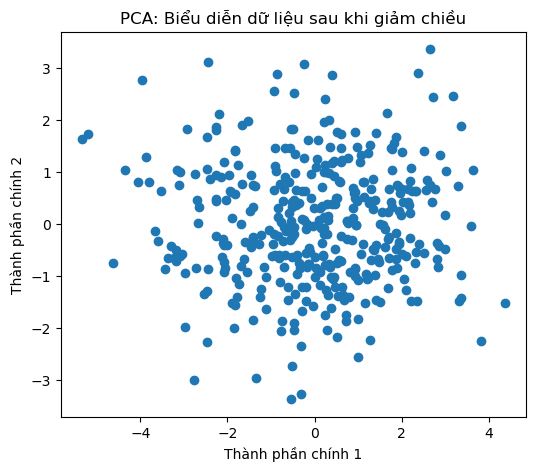

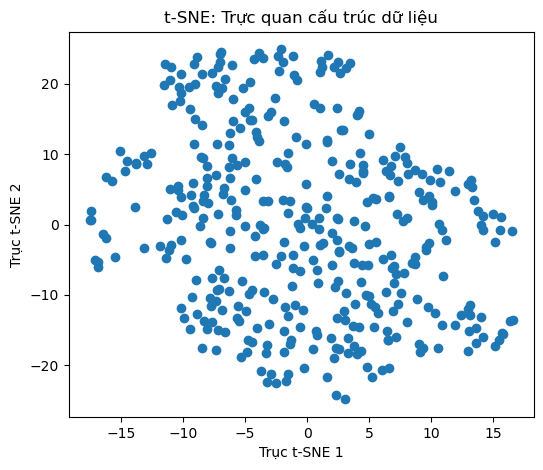


✅ Hoàn thành PCA và t-SNE


In [28]:
2.4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# =========================
# 1. Đọc dữ liệu
# =========================
df = pd.read_csv(r'E:/student-mat.csv', sep=',')

# =========================
# 2. Chọn thuộc tính
# =========================
cols = [
    'G1', 'G2', 'G3',
    'studytime', 'failures',
    'absences', 'goout',
    'freetime', 'health'
]

X = df[cols]

# =========================
# 3. Chuẩn hóa dữ liệu
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================
# 4. PCA (giảm về 2 chiều)
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================
# 5. Vẽ PCA
# =========================
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel('Thành phần chính 1')
plt.ylabel('Thành phần chính 2')
plt.title('PCA: Biểu diễn dữ liệu sau khi giảm chiều')
plt.show()

# =========================
# 6. t-SNE
# =========================
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# =========================
# 7. Vẽ t-SNE
# =========================
plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1])
plt.xlabel('Trục t-SNE 1')
plt.ylabel('Trục t-SNE 2')
plt.title('t-SNE: Trực quan cấu trúc dữ liệu')
plt.show()

print("\n✅ Hoàn thành PCA và t-SNE")